In [1]:
import pandas as pd
from scipy.stats import pearsonr

df = pd.read_csv("data_uji_reliabilitas_validitas.csv")

item_cols = [col for col in df.columns if df[col].dtype != 'object']

results = []

for item in item_cols:
    total_excl = df[item_cols].drop(columns=[item]).sum(axis=1)
    r, p = pearsonr(df[item], total_excl)
    results.append([item, round(r, 4), round(p, 4), "Valid" if r >= 0.30 else "Tidak Valid"])

hasil = pd.DataFrame(results, columns=["Item", "r_item_total", "p_value", "Kesimpulan"])
print(hasil)


   Item  r_item_total  p_value Kesimpulan
0    D1        0.5554      0.0      Valid
1    D2        0.5882      0.0      Valid
2    D3        0.5950      0.0      Valid
3    D4        0.6123      0.0      Valid
4    D5        0.6196      0.0      Valid
5    D6        0.6674      0.0      Valid
6    D7        0.6432      0.0      Valid
7    A1        0.5663      0.0      Valid
8    A2        0.6055      0.0      Valid
9    A3        0.5971      0.0      Valid
10   A4        0.6060      0.0      Valid
11   A5        0.6978      0.0      Valid
12   A6        0.6982      0.0      Valid
13   A7        0.7353      0.0      Valid
14   S1        0.5419      0.0      Valid
15   S2        0.5508      0.0      Valid
16   S3        0.5658      0.0      Valid
17   S4        0.6727      0.0      Valid
18   S5        0.6270      0.0      Valid
19   S6        0.6068      0.0      Valid
20   S7        0.6831      0.0      Valid



=== HASIL UJI RELIABILITAS (Cronbach's Alpha) ===
Alpha Depresi   : 0.8394
Alpha Kecemasan : 0.8545
Alpha Stres     : 0.8327

=== VALIDITAS DEPRESI ===
  Item         r        p-value Keterangan
0   D1  0.486070   9.991668e-52      Valid
1   D2  0.546510   1.638632e-67      Valid
2   D3  0.532179   1.778725e-63      Valid
3   D4  0.587918   2.437054e-80      Valid
4   D5  0.622878   1.042950e-92      Valid
5   D6  0.693856  2.434761e-123      Valid
6   D7  0.671599  8.170414e-113      Valid

=== VALIDITAS KECEMASAN ===
  Item         r        p-value Keterangan
0   A1  0.550750   9.608849e-69      Valid
1   A2  0.564688   6.399737e-73      Valid
2   A3  0.576471   1.310215e-76      Valid
3   A4  0.576120   1.695067e-76      Valid
4   A5  0.682490  7.566890e-118      Valid
5   A6  0.685458  2.943474e-119      Valid
6   A7  0.682622  6.559140e-118      Valid

=== VALIDITAS STRES ===
  Item         r        p-value Keterangan
0   S1  0.492766   2.529076e-53      Valid
1   S2  0.508308   

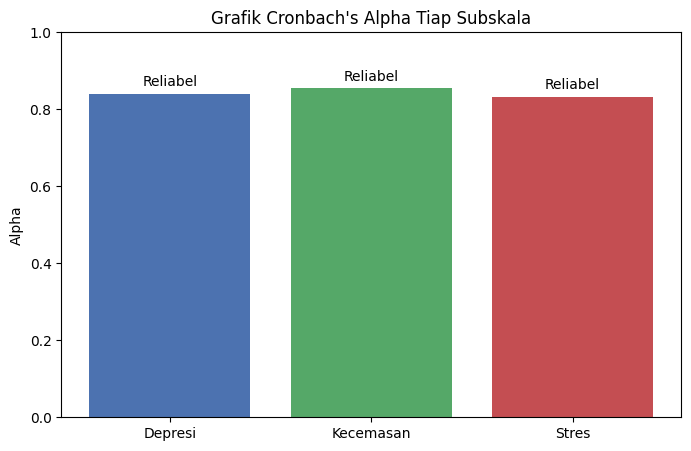

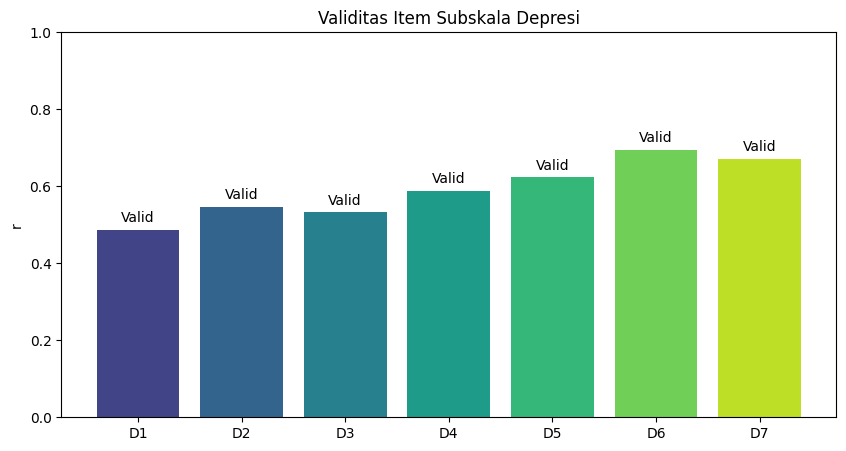

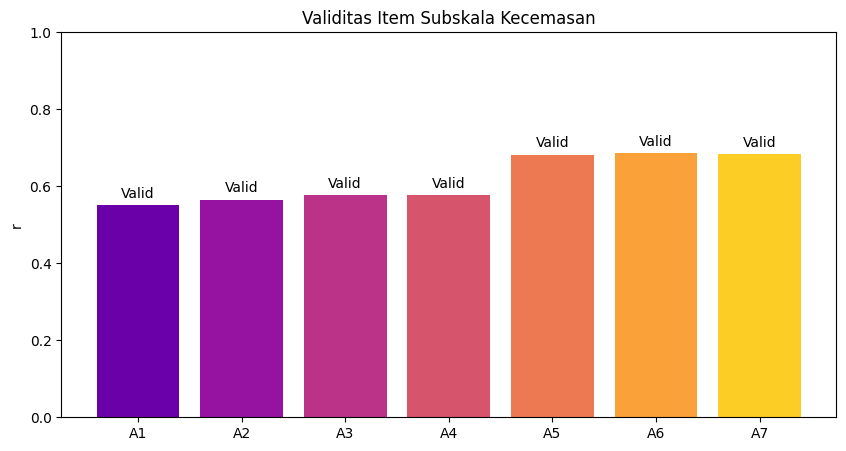

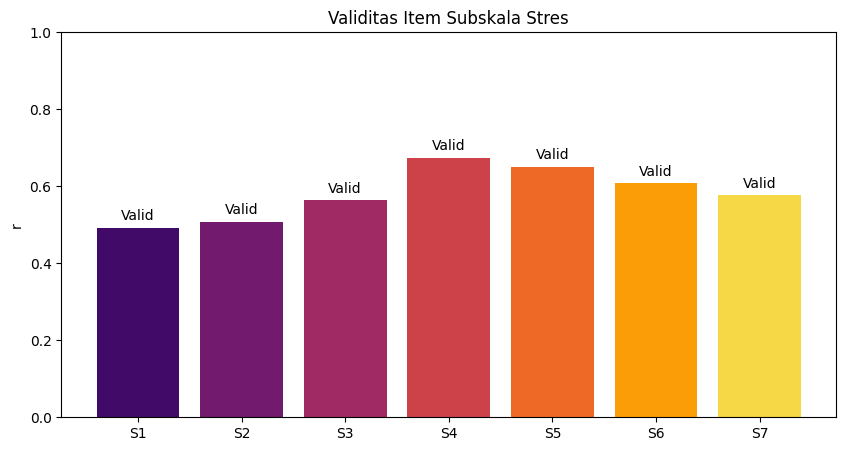

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv("data_uji_reliabilitas_validitas.csv")

depresi = ["D1","D2","D3","D4","D5","D6","D7"]
kecemasan = ["A1","A2","A3","A4","A5","A6","A7"]
stres = ["S1","S2","S3","S4","S5","S6","S7"]
all_items = depresi + kecemasan + stres

def cronbach_alpha(data):
    item_vars = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    k = data.shape[1]
    return (k/(k-1)) * (1 - item_vars.sum()/total_var)

alpha_dep = cronbach_alpha(df[depresi])
alpha_kec = cronbach_alpha(df[kecemasan])
alpha_str = cronbach_alpha(df[stres])

print("\n=== HASIL UJI RELIABILITAS (Cronbach's Alpha) ===")
print("Alpha Depresi   :", round(alpha_dep, 4))
print("Alpha Kecemasan :", round(alpha_kec, 4))
print("Alpha Stres     :", round(alpha_str, 4))

def kategori_reliabilitas(a):
    if a >= 0.90: return "Sangat Reliabel"
    elif a >= 0.80: return "Reliabel"
    elif a >= 0.70: return "Cukup Reliabel"
    else: return "Tidak Reliabel"

def uji_validitas(df, item_list):
    hasil = []
    for item in item_list:
        total_excluding = df[item_list].drop(columns=[item]).sum(axis=1)
        r, p = pearsonr(df[item], total_excluding)
        hasil.append([item, r, p, "Valid" if r >= 0.30 else "Tidak Valid"])
    return pd.DataFrame(hasil, columns=["Item", "r", "p-value", "Keterangan"])

valid_dep = uji_validitas(df, depresi)
valid_kec = uji_validitas(df, kecemasan)
valid_str = uji_validitas(df, stres)

print("\n=== VALIDITAS DEPRESI ===")
print(valid_dep)
print("\n=== VALIDITAS KECEMASAN ===")
print(valid_kec)
print("\n=== VALIDITAS STRES ===")
print(valid_str)

valid_dep.to_csv("validitas_depresi.csv", index=False)
valid_kec.to_csv("validitas_kecemasan.csv", index=False)
valid_str.to_csv("validitas_stres.csv", index=False)

print("\nHasil validitas telah disimpan sebagai CSV.")

plt.figure(figsize=(8,5))
labels = ["Depresi","Kecemasan","Stres"]
values = [alpha_dep, alpha_kec, alpha_str]
colors_rel = ["#4C72B0", "#55A868", "#C44E52"]
bars = plt.bar(labels, values, color=colors_rel)
plt.title("Grafik Cronbach's Alpha Tiap Subskala")
plt.ylabel("Alpha")
plt.ylim(0,1)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, kategori_reliabilitas(val), ha='center')
plt.show()

plt.figure(figsize=(10,5))
colors_dep = plt.cm.viridis(np.linspace(0.2, 0.9, len(valid_dep)))
bars = plt.bar(valid_dep["Item"], valid_dep["r"], color=colors_dep)
plt.title("Validitas Item Subskala Depresi")
plt.ylabel("r")
plt.ylim(0,1)
for bar, val in zip(bars, valid_dep["r"]):
    ket = "Valid" if val >= 0.30 else "Tidak Valid"
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, ket, ha='center')
plt.show()

plt.figure(figsize=(10,5))
colors_kec = plt.cm.plasma(np.linspace(0.2, 0.9, len(valid_kec)))
bars = plt.bar(valid_kec["Item"], valid_kec["r"], color=colors_kec)
plt.title("Validitas Item Subskala Kecemasan")
plt.ylabel("r")
plt.ylim(0,1)
for bar, val in zip(bars, valid_kec["r"]):
    ket = "Valid" if val >= 0.30 else "Tidak Valid"
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, ket, ha='center')
plt.show()

plt.figure(figsize=(10,5))
colors_str = plt.cm.inferno(np.linspace(0.2, 0.9, len(valid_str)))
bars = plt.bar(valid_str["Item"], valid_str["r"], color=colors_str)
plt.title("Validitas Item Subskala Stres")
plt.ylabel("r")
plt.ylim(0,1)
for bar, val in zip(bars, valid_str["r"]):
    ket = "Valid" if val >= 0.30 else "Tidak Valid"
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02, ket, ha='center')
plt.show()

heat_df = pd.DataFrame({
    "Item": valid_dep["Item"].tolist() + valid_kec["Item"].tolist() + valid_str["Item"].tolist(),
    "r": valid_dep["r"].tolist() + valid_kec["r"].tolist() + valid_str["r"].tolist(),
    "Subskala": ["Depresi"]*7 + ["Kecemasan"]*7 + ["Stres"]*7
})

pivot = heat_df.pivot("Subskala","Item","r")

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Heatmap Validitas Item DASS-21")
plt.tight_layout()
plt.show()



=== HASIL UJI RELIABILITAS ===
Depresi   : 0.8394
Kecemasan : 0.8545
Stres     : 0.8327


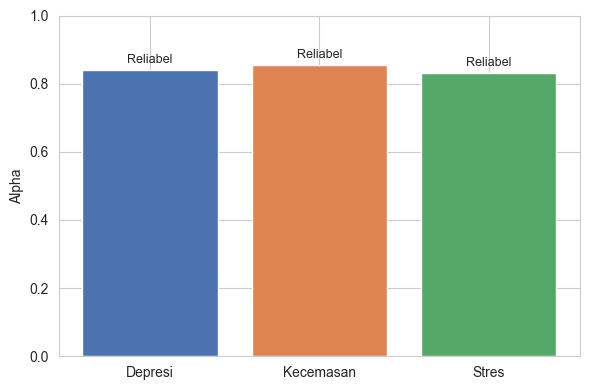

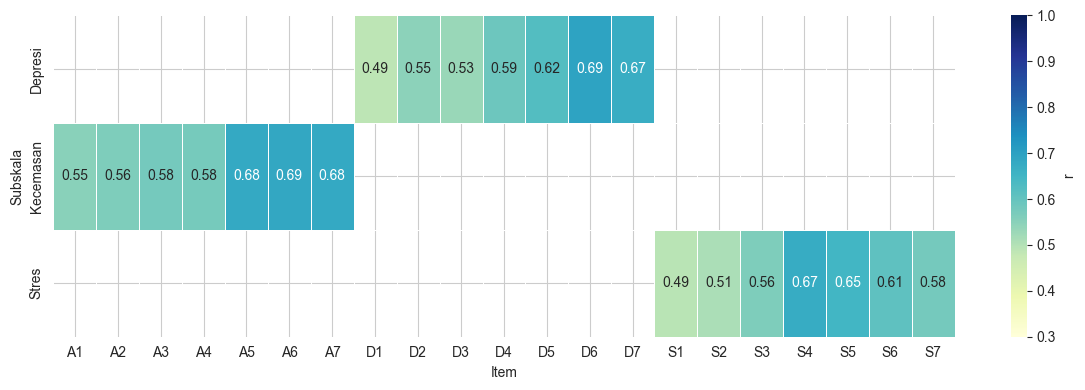

In [2]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("data_uji_reliabilitas_validitas.csv")

depresi = ["D1","D2","D3","D4","D5","D6","D7"]
kecemasan = ["A1","A2","A3","A4","A5","A6","A7"]
stres = ["S1","S2","S3","S4","S5","S6","S7"]

def cronbach_alpha(data):
    item_vars = data.var(axis=0, ddof=1)
    total_var = data.sum(axis=1).var(ddof=1)
    k = data.shape[1]
    return (k/(k-1)) * (1 - item_vars.sum()/total_var)

alpha_dep = cronbach_alpha(df[depresi])
alpha_kec = cronbach_alpha(df[kecemasan])
alpha_str = cronbach_alpha(df[stres])

print("\n=== HASIL UJI RELIABILITAS ===")
print("Depresi   :", round(alpha_dep, 4))
print("Kecemasan :", round(alpha_kec, 4))
print("Stres     :", round(alpha_str, 4))

def kategori_reliabilitas(a):
    if a >= 0.90: return "Sangat Reliabel"
    elif a >= 0.80: return "Reliabel"
    elif a >= 0.70: return "Cukup"
    else: return "Tidak"

def uji_validitas(df, item_list):
    hasil = []
    for item in item_list:
        total_excluding = df[item_list].drop(columns=[item]).sum(axis=1)
        r, p = pearsonr(df[item], total_excluding)
        hasil.append([item, r, p, "Valid" if r >= 0.30 else "Tidak"])
    return pd.DataFrame(hasil, columns=["Item", "r", "p", "Ket"])

valid_dep = uji_validitas(df, depresi)
valid_kec = uji_validitas(df, kecemasan)
valid_str = uji_validitas(df, stres)

# ===============================
# RELIABILITAS (BAR CHART CLEAN)
# ===============================
plt.figure(figsize=(6,4))
labels = ["Depresi","Kecemasan","Stres"]
values = [alpha_dep, alpha_kec, alpha_str]
colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = plt.bar(labels, values, color=colors)

plt.ylabel("Alpha")
plt.ylim(0,1)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             kategori_reliabilitas(val),
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ===============================
# VALIDITAS (HEATMAP)
# ===============================
heat_df = pd.DataFrame({
    "Item": valid_dep["Item"].tolist() +
            valid_kec["Item"].tolist() +
            valid_str["Item"].tolist(),
    "r": valid_dep["r"].tolist() +
         valid_kec["r"].tolist() +
         valid_str["r"].tolist(),
    "Subskala": ["Depresi"]*7 + ["Kecemasan"]*7 + ["Stres"]*7
})

pivot = heat_df.pivot(index="Subskala", columns="Item", values="r")

plt.figure(figsize=(12,4))
sns.heatmap(
    pivot,
    annot=True,
    cmap="YlGnBu",
    vmin=0.3,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "r"}
)

plt.tight_layout()
plt.show()